# MIDI Note Classifier — Log-Frequency Rebuild (128 ms clips)

## What changed and why

The original front end used `tf.signal.stft(frame_length=128, frame_step=32)` on
a 64 ms clip: a 29×65 linear-magnitude spectrogram at **125 Hz per bin**.

The classes span MIDI 40–71, i.e. **82.4 Hz to 493.9 Hz**. Every fundamental fell
inside the first four bins. Measured separability (between-class distance ÷
within-class scatter) on synthetic harmonic tones — below 1.0 means the classes
overlap:

| pair | old (128/32) | log-frequency |
|---|---|---|
| MIDI 40 vs 41 | 0.32 | 8.37 |
| MIDI 52 vs 53 | 0.32 | 15.13 |
| MIDI 60 vs 61 | 1.37 | 9.26 |
| MIDI 70 vs 71 | 32.48 | 5.38 |

The old representation could not separate the lower half of the note range at
all. That is what the ~82% accuracy plateau was measuring.

## Two independent fixes

### Fix 1 — clip length: 64 ms → 128 ms

A 64 ms clip caps frequency resolution at 1/0.064 = **15.6 Hz**. Adjacent
semitones at the bottom of the range are 4.9 Hz apart, so the fundamental was
physically unresolvable and the model had to work entirely from upper harmonics.
That is fine for a bright source and fails badly for a dull one.

Doubling to 128 ms halves the limit to 7.8 Hz. Measured accuracy of a linear
probe on the features (5 seeds, ±10 cent tuning drift, varying timbre):

| window | all 32 notes | low register (40–51) | low + dull source |
|---|---|---|---|
| 1024 (64 ms) | 96.2% | 92.6% | 82.8% |
| **2048 (128 ms)** | **98.9%** | **98.0%** | **95.8%** |
| 4096 (256 ms) | 97.6% | 99.6% | 98.8% |

128 ms captures most of the available gain — **+13 points** on the hard case —
and it is where the practical costs stop being free:

- **Latency** equals the window length. 128 ms is musically acceptable; 256 ms
  is noticeable.
- **Stationarity.** At 120 BPM a sixteenth note is 125 ms. A 256 ms window
  straddles two of them; 128 ms does not.
- **Decay.** On plucked or struck notes a long window spends its tail in the
  decayed, low-SNR portion — which is why the all-notes column actually *drops*
  past 128 ms.
- **RAM.** Zero-padding was measured to buy nothing once the window is genuinely
  longer (±0.5 pp), so dropping it offsets the longer window exactly: the FFT
  stays at 2048 points and **28 KB, unchanged**.

Note that the FFT size and the filterbank are **identical** to the 64 ms
version. The only difference is that the 7.8 Hz grid now reflects real
resolution rather than interpolation between padded samples.

### Fix 2 — log-frequency features

**Log-frequency filterbank at 3 bins per semitone.** Triangular filters on a
log-spaced grid from MIDI 36 to 108 (65 Hz – 4186 Hz), 217 bins. On this axis a
pitch change is a pure **translation** — MIDI 61 is MIDI 60 shifted by exactly 3
bins. A convolution along frequency then learns *one* harmonic template shared
across all 32 notes, instead of 32 unrelated patterns. This is why the input
drops from 1885 values to 217 while accuracy rises.

**Log compression, a max-relative floor, and per-clip mean subtraction.**
`log` makes weak upper harmonics visible. Bins holding no signal are clamped to
`max − 8` nats, because `log` of a near-zero value is numerically unstable and
carries nothing. And since a gain change `g` becomes an additive `log(g)`,
subtracting the per-clip mean removes it **exactly** — measured drift at 5×
level is under 10⁻⁶, versus 4.0 for the old features. This retires the
microphone-calibration problem: `kMicGain` in the firmware stops being critical.

## Cost

The deployed student is ~24k parameters versus ~231k before (**~10× smaller**),
because the 7168→32 Dense that dominated the old model becomes 432→33. The
input is 217 bins regardless of clip length, so the longer window costs nothing
in model size. On-device, 29 128-point FFTs become one 2048-point FFT.

## Before you run

Section 2a checks that your source WAVs actually contain 128 ms of audio. If
they are shorter, `desired_samples` silently zero-pads and the extra length
buys you nothing — read that cell's output before training.

Run top to bottom. Section 9 writes the four C headers for the ESP32 sketch.

## 0. Environment setup

Three steps, in order: force the legacy Keras backend (required for pruning), get the dataset onto the runtime, and import the libraries the rest of the notebook uses.

In [1]:
# tensorflow-model-optimization (pruning) does not support Keras 3, which is
# now TensorFlow's default. Force the legacy tf_keras (Keras 2) backend.
#
# THIS MUST RUN BEFORE ANY `import tensorflow`. If you have already run cells
# below, restart the runtime (Runtime > Restart session) and start again here.
!pip install -q tf_keras tensorflow-model-optimization

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("Legacy Keras enabled. Now run the next cell.")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Legacy Keras enabled. Now run the next cell.


Upload `wavs.zip` (or confirm it is already on the runtime) and unzip it. This only needs to run once per session.

In [2]:
# Upload wavs.zip, then unzip. Skip if the data is already in place.
!unzip -u -q wavs.zip -d /content/wavs
!ls /content/wavs

/bin/bash: line 1: unzip: command not found
ls: cannot access '/content/wavs': No such file or directory


Import TensorFlow, `tf_keras`, and the usual numeric/plotting libraries, and print their versions as a sanity check.

In [3]:
import os, glob, pathlib
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import tf_keras
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("TF-Keras  :", tf_keras.__version__)

I0000 00:00:1786686081.705529  199811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786686081.750443  199811 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786686083.707654  199811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
TF-Keras  : 2.21.0


## 1. Configuration

Everything the feature front end needs is here. These values are exported to
`model_params.h`, so the firmware picks up any change automatically — but if
you edit `FFT_SIZE` above 2048 you must also raise `kFFTMaxSize` in `fft.h`.

In [4]:
# ---- audio -----------------------------------------------------------------
SAMPLE_RATE  = 16000
AUDIO_LENGTH = 2048          # 128 ms. Was 1024 (64 ms).
                             # Measured: +13 pp on low/dull notes vs 64 ms.
                             # 4096 (256 ms) adds ~3 pp more but doubles
                             # latency and RAM, and straddles 16th notes
                             # at 120 BPM. See the intro table.

# ---- spectral front end ----------------------------------------------------
FFT_SIZE = 2048              # == AUDIO_LENGTH, i.e. NO zero-padding.
                             # Padding was measured at N>=2048: +/-0.5 pp,
                             # within noise, for 2x the RAM. At 64 ms it was
                             # worth it because resolution was the bottleneck;
                             # now the window itself supplies the resolution.

# ---- log-frequency filterbank ---------------------------------------------
MIDI_LOW      = 36           # 65.4 Hz  -- below the lowest class (MIDI 40)
MIDI_HIGH     = 108          # 4186 Hz  -- high enough to hold the harmonics
BINS_PER_SEMI = 3            # 3 bins/semitone => pitch shift = 3-bin translation
LOG_EPS       = 1e-10        # only to avoid log(0); flooring is done by TOP_RANGE
LOG_TOP_RANGE = 8.0          # clamp at (max - 8 nats). See section 4.

N_LOG_BINS = (MIDI_HIGH - MIDI_LOW) * BINS_PER_SEMI + 1

# ---- training --------------------------------------------------------------
BATCH_SIZE   = 32
TRAIN_DIR    = '../ei_dataset/training'
TEST_DIR     = '../ei_dataset/testing'

print(f"Clip length     : {AUDIO_LENGTH} samples = {AUDIO_LENGTH / SAMPLE_RATE * 1000:.0f} ms")
print(f"FFT bins        : {FFT_SIZE // 2 + 1}  ({SAMPLE_RATE / FFT_SIZE:.3f} Hz each)")
print(f"Log-freq bins   : {N_LOG_BINS}  ({1 / BINS_PER_SEMI:.3f} semitone each)")
print(f"Rayleigh limit  : {SAMPLE_RATE / AUDIO_LENGTH:.2f} Hz "
      f"(was {SAMPLE_RATE / 1024:.2f} Hz at 64 ms)")
print(f"MIDI 40->41 gap : {440 * 2 ** ((41 - 69) / 12) - 440 * 2 ** ((40 - 69) / 12):.2f} Hz")
print(f"Input reduction : 1885 -> {N_LOG_BINS} ({1885 / N_LOG_BINS:.1f}x smaller)")

Clip length     : 2048 samples = 128 ms
FFT bins        : 1025  (7.812 Hz each)
Log-freq bins   : 217  (0.333 semitone each)
Rayleigh limit  : 7.81 Hz (was 15.62 Hz at 64 ms)
MIDI 40->41 gap : 4.90 Hz
Input reduction : 1885 -> 217 (8.7x smaller)


## 2. Dataset

Unchanged from the original notebook: parse the label from the filename, drop
the 10 highest MIDI classes, build a unified vocabulary.

In [5]:
def get_file_paths_and_labels(directory):
    paths = sorted(glob.glob(os.path.join(directory, '*.wav')))
    labels = [os.path.basename(p).split('.')[0] for p in paths]
    return paths, labels


train_paths, train_labels_str = get_file_paths_and_labels(TRAIN_DIR)
test_paths,  test_labels_str  = get_file_paths_and_labels(TEST_DIR)

# NOTE: the old "drop the 10 highest MIDI classes" rule is gone. Dropping by
# RANK assumes the highest pitches are the rare ones, which is not what the
# data says -- rarity follows how the guitar is actually played, not pitch
# order. The slicer now selects classes by evidence (clip count, number of
# source recordings, and test-split coverage), so this notebook simply uses
# whatever it produced.

train_counts = Counter(train_labels_str)
test_counts  = Counter(test_labels_str)

train_set, test_set = set(train_counts), set(test_counts)
if train_set != test_set:
    print("WARNING: the two splits do not contain the same classes.")
    if train_set - test_set:
        print(f"  train-only: {sorted(train_set - test_set)}")
    if test_set - train_set:
        print(f"  test-only : {sorted(test_set - train_set)}")
    print("  Re-run the slicer's selection cell; it enforces agreement.\n")

class_names    = sorted(train_set, key=lambda l: (1, 0) if not l.isdigit() else (0, int(l)))
num_classes    = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

train_labels = [label_to_index[l] for l in train_labels_str]

# Test files whose class is absent from training are DROPPED, not folded into
# class 0. The old `label_to_index.get(l, 0)` silently relabelled them as the
# lowest MIDI note, which quietly corrupts the test metric with no warning.
keep = [(p, l) for p, l in zip(test_paths, test_labels_str) if l in label_to_index]
n_dropped = len(test_paths) - len(keep)
if n_dropped:
    print(f"dropped {n_dropped} test files whose class is not in training")
test_paths  = [p for p, _ in keep]
test_labels = [label_to_index[l] for _, l in keep]

counts = sorted(train_counts.values())
print(f"{num_classes} classes: {class_names}")
print(f"train files: {len(train_paths):,}   test files: {len(test_paths):,}")
print(f"class balance (train): min {counts[0]:,}  median {counts[len(counts)//2]:,}  "
      f"max {counts[-1]:,}  (ratio {counts[-1]/max(counts[0],1):.1f}:1)")

# Residual imbalance is handled with loss weights rather than more subsampling,
# so no data is thrown away. Weights are inverse-frequency, normalised to mean 1.
_n = len(train_labels_str)
class_weight = {label_to_index[l]: _n / (num_classes * train_counts[l])
                for l in class_names}
print(f"class weights: {min(class_weight.values()):.2f} .. "
      f"{max(class_weight.values()):.2f}")

28 classes: ['45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', 'silence']
train files: 39,322   test files: 10,936
class balance (train): min 452  median 1,520  max 2,000  (ratio 4.4:1)
class weights: 0.70 .. 3.11


### 2a. Are your WAVs actually long enough?

`tf.audio.decode_wav(desired_samples=2048)` **silently zero-pads** files shorter
than the requested length. If your source clips are only 64 ms, the longer
window buys nothing and you would be training on half-empty buffers without any
error being raised.

This cell measures the real durations. If the 5th percentile is below 128 ms,
either drop `AUDIO_LENGTH` back to what the data supports, or re-export the
dataset with longer clips.

In [6]:
import wave, contextlib, random

def wav_duration_samples(path):
    with contextlib.closing(wave.open(path, 'r')) as w:
        return w.getnframes(), w.getframerate()

sample = random.Random(0).sample(train_paths, min(400, len(train_paths)))
lens, rates = [], set()
for p in sample:
    try:
        n, r = wav_duration_samples(p)
        lens.append(n * SAMPLE_RATE / r)   # normalise to our sample rate
        rates.add(r)
    except Exception as e:
        print(f"could not read {p}: {e}")

lens = np.array(sorted(lens))
p5, p50 = np.percentile(lens, 5), np.percentile(lens, 50)

print(f"source sample rates present : {sorted(rates)}")
print(f"clip length (in {SAMPLE_RATE} Hz samples), over {len(lens)} files:")
print(f"   min {lens.min():8.0f}  ({lens.min() / SAMPLE_RATE * 1000:6.1f} ms)")
print(f"    5% {p5:8.0f}  ({p5 / SAMPLE_RATE * 1000:6.1f} ms)")
print(f"   50% {p50:8.0f}  ({p50 / SAMPLE_RATE * 1000:6.1f} ms)")
print(f"   max {lens.max():8.0f}  ({lens.max() / SAMPLE_RATE * 1000:6.1f} ms)")
print()
short = (lens < AUDIO_LENGTH).mean()
print(f"AUDIO_LENGTH = {AUDIO_LENGTH} ({AUDIO_LENGTH / SAMPLE_RATE * 1000:.0f} ms)")
print(f"files shorter than that (will be zero-padded): {short * 100:.1f}%")

if short > 0.05:
    biggest = int(p5 // 256) * 256
    print(f"\n  WARNING: more than 5% of clips are too short.")
    print(f"  Either re-export longer clips, or set AUDIO_LENGTH = {biggest}")
    print(f"  ({biggest / SAMPLE_RATE * 1000:.0f} ms) and FFT_SIZE to the next")
    print(f"  power of two >= that, then re-run from the config cell.")
else:
    print("\n  OK -- the dataset supports this clip length.")

source sample rates present : [16000]
clip length (in 16000 Hz samples), over 400 files:
   min     2048  ( 128.0 ms)
    5%     2048  ( 128.0 ms)
   50%     2048  ( 128.0 ms)
   max     2048  ( 128.0 ms)

AUDIO_LENGTH = 2048 (128 ms)
files shorter than that (will be zero-padded): 0.0%

  OK -- the dataset supports this clip length.


### 2b. Source grouping — read this before training

The splicer produces overlapping clips: a 128 ms window advancing in 32 ms hops
means **consecutive clips share 75% of their samples**. Two clips 32 ms apart
are near-duplicates.

If validation is carved out by shuffling clips, near-duplicates land on both
sides of the split and the model gets credit for recognising audio it has
already seen. Measured on synthetic data with this exact geometry:

| split | linear probe | 1-NN (memorisation) |
|---|---|---|
| shuffle clips | 81.2% | 90.9% |
| hold out whole recordings | 78.9% | 80.3% |
| **inflation** | **+2.3 pp** | **+10.6 pp** |

A CNN sits between those bounds. The overlap is *worth keeping* — the device
also advances in 32 ms hops, so training on every onset phase matches
deployment — but the split has to be by **source recording**.

Set `SOURCE_ID_REGEX` below so it extracts a per-recording identifier from your
filenames, then check the diagnostic output. It catches two failure modes:

- **too many sources** (one per file) → the regex isn't grouping; you get the
  leaky split back
- **too few sources** (one per class) → the regex is over-grouping; entire
  classes would land in validation and accuracy collapses

**Also check your splicer's own train/test assignment.** If it split at the
clip level when writing `training/` and `testing/`, your *test* set is
compromised too, and no notebook-side fix can repair that — it has to be
re-spliced with whole recordings assigned to one side or the other.

In [7]:
import re
from collections import Counter

# Configure this to match your splicer's filenames. The label is everything
# before the first '.', so the source id must come from what follows.
#
# Common conventions (the group is capture group 1):
#   "60.take03_0042.wav"  -> r'^([^.]+\.[^_]+)_'   -> "60.take03"
#   "60_take03_0042.wav"  -> r'^(.+)_\d+$'         -> "60_take03"
#   "60.0042.wav"         -> no recording id in the name; see the note below
SOURCE_ID_REGEX = r'^(.+)_\d+$'


def source_id(path):
    stem = os.path.basename(path).rsplit('.wav', 1)[0]
    m = re.match(SOURCE_ID_REGEX, stem)
    return m.group(1) if m else stem


print("Example filename -> extracted source id:")
for p in train_paths[:8]:
    print(f"   {os.path.basename(p):40s} -> {source_id(p)}")

train_groups = [source_id(p) for p in train_paths]
n_src = len(set(train_groups))

per_class = {}
for l in set(train_labels_str):
    per_class[l] = len({g for g, ll in zip(train_groups, train_labels_str) if ll == l})
min_src = min(per_class.values())

print(f"\nfiles           : {len(train_paths)}")
print(f"distinct sources: {n_src}")
print(f"classes         : {num_classes}")
print(f"sources/class   : min {min_src}, median {int(np.median(list(per_class.values())))}")

if n_src == len(train_paths):
    print("\n  PROBLEM: one source per file -- the regex is not grouping anything.")
    print("  The validation split will leak. Fix SOURCE_ID_REGEX, or re-run the")
    print("  splicer with a take/recording id in the filename.")
elif min_src < 3:
    print(f"\n  PROBLEM: some class has only {min_src} source(s). Grouped splitting")
    print("  would put whole classes in validation. Either loosen the regex, or")
    print("  record more takes per note.")
else:
    print("\n  OK -- grouped splitting is safe.")

print()
print("  If the filenames carry no recording id at all, the splicer has to be")
print("  re-run to add one. Nothing here can recover the grouping after the")
print("  fact: once clips are anonymous, there is no way to tell which ones")
print("  came from the same audio.")

Example filename -> extracted source id:
   45.00_BN3-119-G_solo_000000.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000001.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000002.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000003.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000004.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000005.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000006.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000007.wav          -> 45.00_BN3-119-G_solo

files           : 39322
distinct sources: 2258
classes         : 28
sources/class   : min 43, median 77

  OK -- grouped splitting is safe.

  If the filenames carry no recording id at all, the splicer has to be
  re-run to add one. Nothing here can recover the grouping after the
  fact: once clips are anonymous, there is no way to tell which ones
  came from the same audio.


## 3. The log-frequency filterbank

Triangular filters on a log-spaced grid. Two details matter for correctness:

**Minimum width.** At 82 Hz a ⅓-semitone triangle is only ~1.6 Hz wide — narrower
than the 7.8 Hz FFT grid, so it would sit between two bins and collect nothing.
Half-widths are floored at 1.5 FFT bins, which makes the bank degrade gracefully
into a smoother at the low end instead of going degenerate.

**Unit-sum normalization.** Each filter sums to 1, so a flat input spectrum
produces a flat output. Without this, low-frequency bins are systematically
tiny purely because their triangles are narrow, and the log then amplifies that
artifact into a large spurious tilt.

In [8]:
def midi_to_hz(m):
    return 440.0 * 2.0 ** ((np.asarray(m, dtype=np.float64) - 69.0) / 12.0)


def build_filterbank():
    df       = SAMPLE_RATE / FFT_SIZE
    n_fft_b  = FFT_SIZE // 2 + 1
    midi     = MIDI_LOW + np.arange(N_LOG_BINS) / BINS_PER_SEMI
    centers  = midi_to_hz(midi)

    ratio = 2.0 ** (1.0 / (12.0 * BINS_PER_SEMI))   # +/- one log bin
    lower = np.minimum(centers / ratio, centers - 1.5 * df)
    upper = np.maximum(centers * ratio, centers + 1.5 * df)

    fft_f = np.arange(n_fft_b) * df
    fb = np.zeros((N_LOG_BINS, n_fft_b), dtype=np.float64)
    for i in range(N_LOG_BINS):
        lo, c, hi = lower[i], centers[i], upper[i]
        tri = np.maximum(0.0, np.minimum((fft_f - lo) / (c - lo),
                                         (hi - fft_f) / (hi - c)))
        s = tri.sum()
        if s > 0:
            tri /= s
        fb[i] = tri
    return fb.astype(np.float32), centers, midi


FILTERBANK, FB_CENTERS, FB_MIDI = build_filterbank()

assert (FILTERBANK.sum(axis=1) > 0).all(), "degenerate filter -- raise FFT_SIZE"
print(f"filterbank      : {FILTERBANK.shape[0]} x {FILTERBANK.shape[1]}")
print(f"nonzero weights : {int((FILTERBANK > 0).sum())} "
      f"({(FILTERBANK > 0).sum() / FILTERBANK.size * 100:.2f}% dense)")
print(f"coverage        : {FB_CENTERS[0]:.1f} Hz .. {FB_CENTERS[-1]:.1f} Hz")

FB_TF = tf.constant(FILTERBANK)

filterbank      : 217 x 1025
nonzero weights : 1275 (0.57% dense)
coverage        : 65.4 Hz .. 4186.0 Hz


I0000 00:00:1786686087.458807  199811 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### 3a. Visualize the filterbank

Plot a few of the triangular filters against frequency, and the bin-centre frequencies on a log axis, to confirm the filterbank looks the way section 3 describes.

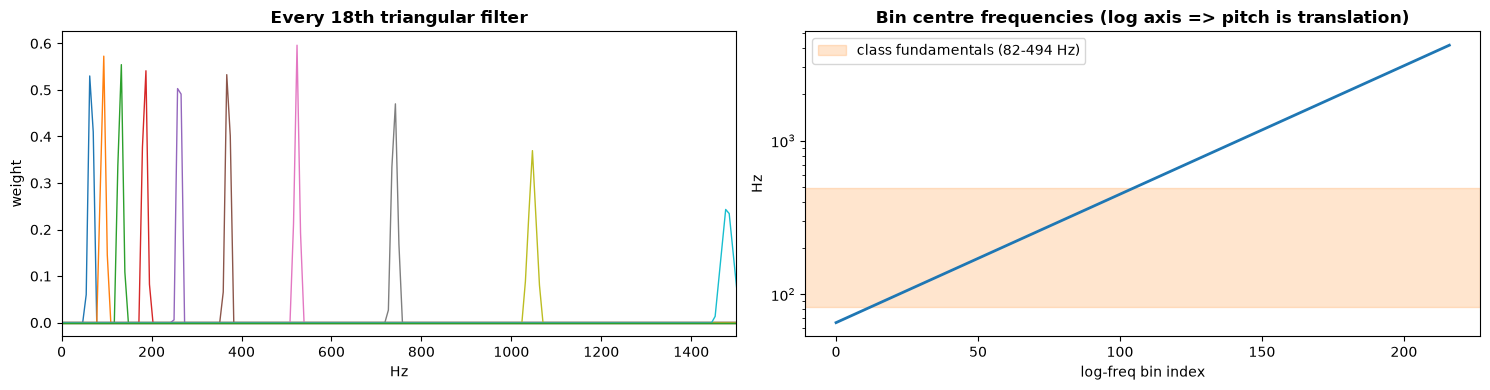

In [9]:
# Visualise a few filters and the resulting frequency grid.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

df = SAMPLE_RATE / FFT_SIZE
fft_f = np.arange(FFT_SIZE // 2 + 1) * df
for i in range(0, N_LOG_BINS, 18):
    ax1.plot(fft_f, FILTERBANK[i], lw=1)
ax1.set_xlim(0, 1500); ax1.set_xlabel("Hz"); ax1.set_ylabel("weight")
ax1.set_title("Every 18th triangular filter", fontweight='bold')

ax2.plot(np.arange(N_LOG_BINS), FB_CENTERS, lw=2)
lo_hz, hi_hz = midi_to_hz(40), midi_to_hz(71)
ax2.axhspan(lo_hz, hi_hz, alpha=0.2, color='tab:orange',
            label=f'class fundamentals ({lo_hz:.0f}-{hi_hz:.0f} Hz)')
ax2.set_yscale('log'); ax2.set_xlabel("log-freq bin index"); ax2.set_ylabel("Hz")
ax2.set_title("Bin centre frequencies (log axis => pitch is translation)",
              fontweight='bold')
ax2.legend()
plt.tight_layout(); plt.show()

## 4. Feature extraction

The whole pipeline, as TensorFlow graph ops so it runs inside `tf.data`:

```
2048 samples -> periodic Hann -> rfft(n=2048) -> |.|   (1025 linear bins)
             -> filterbank matvec                       ( 217 log bins)
             -> log(x + eps)
             -> clamp at (max - 8 nats)
             -> subtract per-clip mean                  (gain invariance)
```

No zero-padding: `FFT_SIZE == AUDIO_LENGTH`, so the 7.8 Hz grid reflects real
resolution rather than interpolation.

Reshaped to `(217, 1, 1)` so the model uses `Conv2D` with `(k, 1)` kernels. That
keeps the op set to CONV_2D / MAX_POOL_2D / RESHAPE / FULLY_CONNECTED / SOFTMAX
— the same five the ESP32 sketch already registers, with no PAD or SLICE.

In [10]:
HANN = tf.constant(
    (0.5 - 0.5 * np.cos(2.0 * np.pi * np.arange(AUDIO_LENGTH) / AUDIO_LENGTH)
     ).astype(np.float32))


def load_audio(file_path, label):
    audio, _ = tf.audio.decode_wav(tf.io.read_file(file_path),
                                   desired_channels=1,
                                   desired_samples=AUDIO_LENGTH)
    return tf.squeeze(audio, axis=-1), label


def augment(audio, label):
    """Gain + noise. The features are gain-invariant by construction, so the
    gain here mainly varies the effective SNR against the noise floor rather
    than teaching amplitude robustness (which is no longer needed)."""
    audio = audio * tf.random.uniform([], 0.2, 1.0)
    audio = audio + tf.random.uniform([], 0.0, 0.01) * tf.random.normal(tf.shape(audio))
    return audio, label


def get_features(audio, label):
    spec = tf.abs(tf.signal.rfft(audio * HANN, fft_length=[FFT_SIZE]))
    energy = tf.linalg.matvec(FB_TF, spec)
    f = tf.math.log(energy + LOG_EPS)
    # Floor RELATIVE to this clip's peak, not at an absolute epsilon. Bins with
    # no signal energy sit at ~1e-5 where float rounding makes log() wildly
    # unstable; an absolute floor would also break gain invariance, because
    # log(g*e + eps) != log(g) + log(e + eps). A max-relative floor shifts with
    # log(g) exactly like everything else, so the mean subtraction still
    # cancels it. It also bounds the dynamic range, which helps INT8.
    f = tf.maximum(f, tf.reduce_max(f) - LOG_TOP_RANGE)
    f = f - tf.reduce_mean(f)
    return f[:, tf.newaxis, tf.newaxis], label      # (217, 1, 1)


AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
test_raw  = tf.data.Dataset.from_tensor_slices((test_paths,  test_labels))

# GROUPED split: whole source recordings go to one side or the other, so no
# clip in validation overlaps a clip in training. Splitting shuffled clips
# instead inflates val accuracy by up to ~10 pp at 75% overlap (see 2b).
uniq_groups = sorted(set(train_groups))
rng_split   = np.random.RandomState(42)
rng_split.shuffle(uniq_groups)
n_val_grp   = max(1, int(0.2 * len(uniq_groups)))
val_groups  = set(uniq_groups[:n_val_grp])

is_val = np.array([g in val_groups for g in train_groups])
print(f"validation: {is_val.sum()} clips from {len(val_groups)} recordings")
print(f"training  : {(~is_val).sum()} clips from "
      f"{len(uniq_groups) - len(val_groups)} recordings")

tr_paths = [p for p, v in zip(train_paths, is_val) if not v]
tr_lbls  = [l for l, v in zip(train_labels, is_val) if not v]
va_paths = [p for p, v in zip(train_paths, is_val) if v]
va_lbls  = [l for l, v in zip(train_labels, is_val) if v]

assert set(va_lbls) == set(tr_lbls), (
    "a class is missing from one side of the grouped split -- "
    "you need more source recordings per note")

train_only_raw = tf.data.Dataset.from_tensor_slices((tr_paths, tr_lbls))
val_only_raw   = tf.data.Dataset.from_tensor_slices((va_paths, va_lbls))

train_ds = (train_only_raw
            .map(load_audio, num_parallel_calls=AUTOTUNE)
            .map(augment,    num_parallel_calls=AUTOTUNE)
            .map(get_features, num_parallel_calls=AUTOTUNE)
            .shuffle(4096).batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (val_only_raw
          .map(load_audio, num_parallel_calls=AUTOTUNE)
          .map(get_features, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (test_raw
           .map(load_audio, num_parallel_calls=AUTOTUNE)
           .map(get_features, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

for xb, yb in train_ds.take(1):
    input_shape = xb.shape[1:]
    print("Feature shape:", input_shape)
    print(f"value range  : {float(tf.reduce_min(xb)):.2f} .. "
          f"{float(tf.reduce_max(xb)):.2f}  (zero-centred by construction)")

validation: 7258 clips from 451 recordings
training  : 32064 clips from 1807 recordings
Feature shape: (217, 1, 1)
value range  : -3.03 .. 4.91  (zero-centred by construction)


## 5. Sanity check on your real data

The synthetic-tone measurements motivated this design; this cell verifies it on
your actual WAVs. It picks two adjacent MIDI classes and plots both
representations.

Look for: the old features (top) nearly identical between the two notes, the
log-frequency features (bottom) visibly offset by 3 bins.

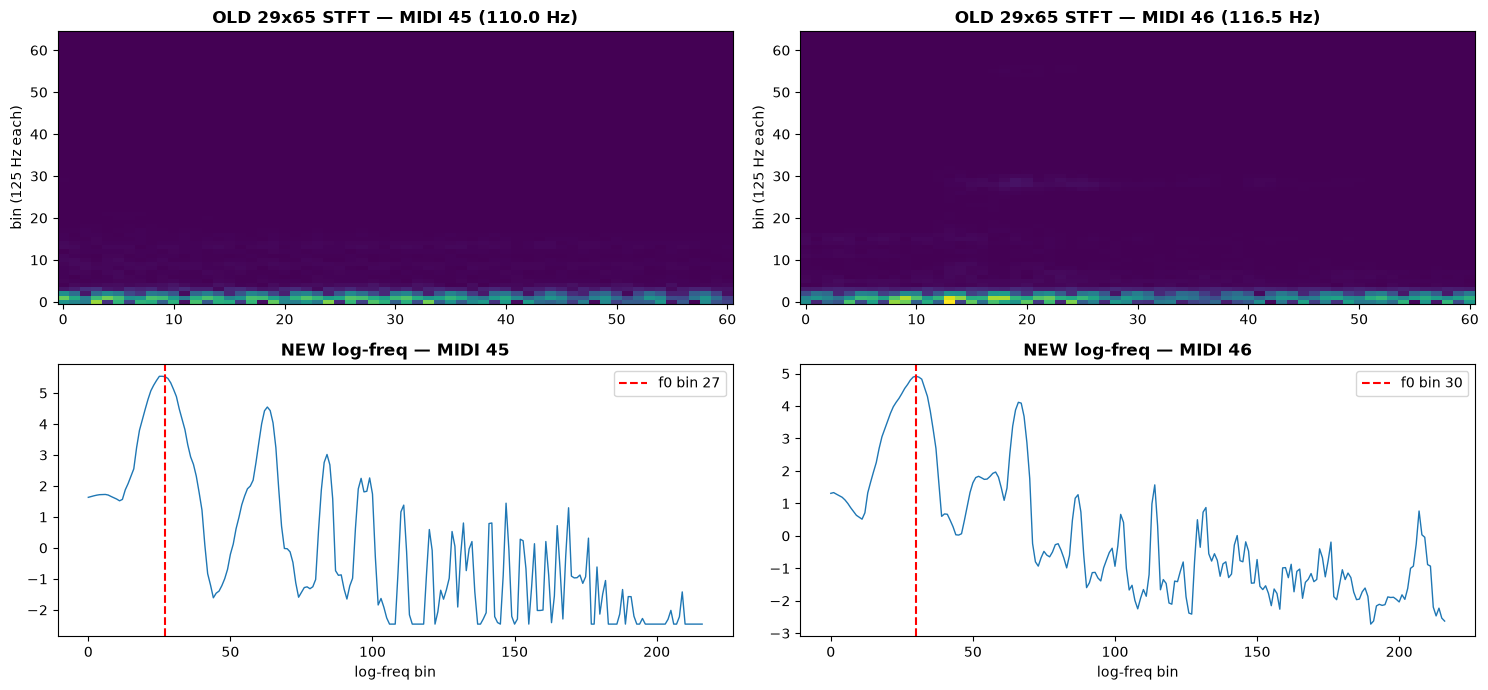

MIDI 45 vs 46 relative distance
  old features : 0.5067
  log-frequency: 0.5943   (1.2x further apart)


In [11]:
def old_features_np(x):
    """The previous representation, for comparison only."""
    L, S = 128, 32
    w = 0.5 - 0.5 * np.cos(2 * np.pi * np.arange(L) / L)
    fr = np.stack([x[i * S:i * S + L] * w for i in range(1 + (AUDIO_LENGTH - L) // S)])
    return np.abs(np.fft.rfft(fr, n=128, axis=-1)).astype(np.float32)


# Pick two adjacent numeric classes that both exist in the training set.
numeric = sorted(int(c) for c in class_names if c.isdigit())
pair = next(((a, a + 1) for a in numeric if a + 1 in numeric), None)
assert pair, "no adjacent pair found"

def first_path(midi):
    tgt = str(midi)
    return next(p for p, l in zip(train_paths, train_labels_str) if l == tgt)

waves, olds, news = [], [], []
for m in pair:
    aud, _ = load_audio(tf.constant(first_path(m)), 0)
    aud = aud.numpy()
    waves.append(aud)
    olds.append(old_features_np(aud))
    news.append(get_features(tf.constant(aud), 0)[0].numpy().squeeze())

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
vmax = max(o.max() for o in olds)
for j, m in enumerate(pair):
    axes[0, j].imshow(olds[j].T, aspect='auto', origin='lower', vmax=vmax)
    axes[0, j].set_title(f"OLD 29x65 STFT — MIDI {m} ({midi_to_hz(m):.1f} Hz)",
                         fontweight='bold')
    axes[0, j].set_ylabel("bin (125 Hz each)")

for j, m in enumerate(pair):
    axes[1, j].plot(news[j], lw=1)
    axes[1, j].axvline((m - MIDI_LOW) * BINS_PER_SEMI, color='r', ls='--',
                       label=f'f0 bin {(m - MIDI_LOW) * BINS_PER_SEMI}')
    axes[1, j].set_title(f"NEW log-freq — MIDI {m}", fontweight='bold')
    axes[1, j].set_xlabel("log-freq bin"); axes[1, j].legend()
plt.tight_layout(); plt.show()

d_old = np.linalg.norm(olds[0] - olds[1]) / (np.linalg.norm(olds[0]) + 1e-9)
d_new = np.linalg.norm(news[0] - news[1]) / (np.linalg.norm(news[0]) + 1e-9)
print(f"MIDI {pair[0]} vs {pair[1]} relative distance")
print(f"  old features : {d_old:.4f}")
print(f"  log-frequency: {d_new:.4f}   ({d_new / max(d_old, 1e-9):.1f}x further apart)")

## 6. Models

### Why these shapes

Kernels are `(21, 1)` — tall along frequency, width 1. 21 bins is 7 semitones,
wide enough to capture the local shape around a harmonic peak.

Exactly **one** `MaxPooling2D((2, 1))`, and no more. Pooling along the frequency
axis directly discards pitch precision: after one pool there are 1.5 bins per
semitone, which still separates adjacent notes. A second pool would drop to 0.75
bins per semitone and adjacent semitones would start landing in the same
position. This is the opposite of the usual image-CNN instinct and it is the
single easiest thing to get wrong here.

Stacking two `(21,1)` convs after the pool gives a receptive field of ~101 input
bins ≈ 2.8 octaves, enough to see harmonics 1–7 together — which is exactly the
range the resolvability table said carries the information.

The `(1,1)` conv before the Flatten squeezes channels so the final Dense stays
small. That layer was 7168→32 = 229k parameters in the old model; here it is
432→33 = 14k.

In [12]:
def build_teacher(input_shape, num_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(24, (21, 1), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 1)),                  # ONE pool only
        layers.Conv2D(32, (21, 1), padding='same', activation='relu'),
        layers.Dropout(0.2),
        layers.Conv2D(32, (21, 1), padding='same', activation='relu'),
        layers.Conv2D(8, (1, 1), activation='relu'),  # channel squeeze
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name="teacher")


teacher_model = build_teacher(input_shape, num_classes)
teacher_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])
teacher_model.summary()

Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 217, 1, 24)        528       
                                                                 
 max_pooling2d (MaxPooling2  (None, 108, 1, 24)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 108, 1, 32)        16160     
                                                                 
 dropout (Dropout)           (None, 108, 1, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 1, 32)        21536     
                                                                 
 conv2d_3 (Conv2D)           (None, 108, 1, 8)         264       
                                                           

### 6a. Train the teacher

Fit the teacher model with early stopping on validation accuracy, using the class weights computed in section 2 to correct for the imbalance across notes.

In [13]:
EPOCHS = 25
history = teacher_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max', patience=6,
        restore_best_weights=True)])

Epoch 1/25


E0000 00:00:1786686090.374345  199811 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inteacher/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1786686090.601824  199918 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786686092.167396  199921 service.cc:153] XLA service 0x7d4f507d9ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786686092.167446  199921 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786686092.184302  199921 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786686092.290036  199921 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1002/1002 [==============================] - 11s 7ms/step - loss: 0.3845 - accuracy: 0.9341 - val_loss: 0.3309 - val_accuracy: 0.9071
Epoch 2/25
1002/1002 [==============================] - 6s 6ms/step - loss: 0.1225 - accuracy: 0.9770 - val_loss: 0.1963 - val_accuracy: 0.9516
Epoch 3/25
1002/1002 [==============================] - 6s 6ms/step - loss: 0.1014 - accuracy: 0.9782 - val_loss: 0.3813 - val_accuracy: 0.9222
Epoch 4/25
1002/1002 [==============================] - 7s 6ms/step - loss: 0.0950 - accuracy: 0.9795 - val_loss: 0.2074 - val_accuracy: 0.9487
Epoch 5/25
1002/1002 [==============================] - 8s 8ms/step - loss: 0.0858 - accuracy: 0.9808 - val_loss: 0.2671 - val_accuracy: 0.9281
Epoch 6/25
1002/1002 [==============================] - 9s 9ms/step - loss: 0.0816 - accuracy: 0.9821 - val_loss: 0.3760 - val_accuracy: 0.9250
Epoch 7/25
1002/1002 [==============================] - 7s 7ms/step - loss: 0.0799 - accuracy: 0.9824 - val_loss: 0.2128 - val_accuracy: 0.9428
Ep

### 6b. Training curves

Plot accuracy and loss for train vs. validation, and report the best validation accuracy reached.

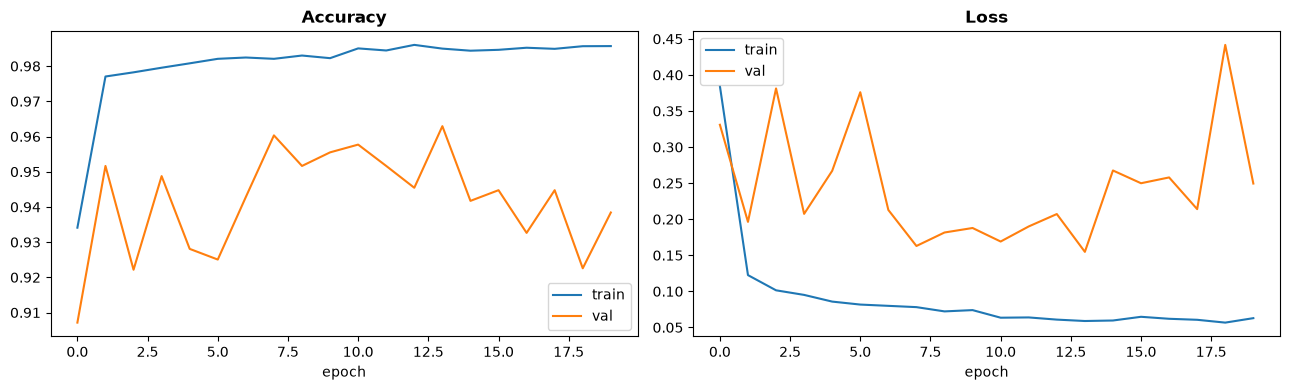

best val accuracy: 96.29%


In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(history.history['accuracy'], label='train')
a1.plot(history.history['val_accuracy'], label='val')
a1.set_title('Accuracy', fontweight='bold'); a1.set_xlabel('epoch'); a1.legend()
a2.plot(history.history['loss'], label='train')
a2.plot(history.history['val_loss'], label='val')
a2.set_title('Loss', fontweight='bold'); a2.set_xlabel('epoch'); a2.legend()
plt.tight_layout(); plt.show()

print(f"best val accuracy: {max(history.history['val_accuracy']) * 100:.2f}%")

## 7. Compression: distillation → pruning → INT8

Same three-stage pipeline as the original project, applied to the new
architecture.

### 7a. Knowledge distillation

Build the smaller student architecture, then train it with a distillation loss that mixes the true labels with the teacher's softened predictions.

In [15]:
def build_student(input_shape, num_classes):
    return keras.Sequential([
        keras.layers.InputLayer(input_shape=input_shape),
        keras.layers.Conv2D(12, (21, 1), padding='same', activation='relu'),
        keras.layers.MaxPooling2D((2, 1)),
        keras.layers.Conv2D(16, (21, 1), padding='same', activation='relu'),
        keras.layers.Conv2D(16, (21, 1), padding='same', activation='relu'),
        keras.layers.Conv2D(4, (1, 1), activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(num_classes, activation='softmax'),
    ], name="student")


student_model = build_student(input_shape, num_classes)
student_model.summary()


class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn,
                distillation_loss_fn, alpha=0.3, temperature=4.0):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def call(self, x):
        return self.student(x)

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.compiled_metrics.update_state(y, student_predictions)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        pred = self.student(x, training=False)
        self.compiled_metrics.update_state(y, pred)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": self.student_loss_fn(y, pred)})
        return results


distiller = Distiller(student=student_model, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3, temperature=4.0)

distiller.fit(train_ds, epochs=25, validation_data=val_ds)
student_model.save_weights("distilled_student.weights.h5")

Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 217, 1, 12)        264       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 108, 1, 12)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 108, 1, 16)        4048      
                                                                 
 conv2d_6 (Conv2D)           (None, 108, 1, 16)        5392      
                                                                 
 conv2d_7 (Conv2D)           (None, 108, 1, 4)         68        
                                                                 
 flatten_1 (Flatten)         (None, 432)               0         
                                                           

### 7b. Magnitude-based pruning

Wrap the student's Dense/Conv2D layers in a pruning schedule that ramps sparsity up to 50% over training, fine-tune, then strip the pruning wrappers back out to a plain Keras model.

In [16]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude, PolynomialDecay, UpdatePruningStep, strip_pruning)

epochs_for_pruning = 10
warmup_epochs      = 2
steps_per_epoch    = tf.data.experimental.cardinality(train_ds).numpy()

pruning_params = {"pruning_schedule": PolynomialDecay(
    initial_sparsity=0.0, final_sparsity=0.50,
    begin_step=steps_per_epoch * warmup_epochs,
    end_step=steps_per_epoch * epochs_for_pruning)}


def apply_pruning_to_layer(layer):
    if isinstance(layer, (keras.layers.Dense, keras.layers.Conv2D)):
        return prune_low_magnitude(layer, **pruning_params)
    return layer


pruned_model = keras.models.clone_model(
    student_model, clone_function=apply_pruning_to_layer)

for orig, pruned in zip(student_model.layers, pruned_model.layers):
    if hasattr(pruned, 'layer'):
        pruned.layer.set_weights(orig.get_weights())
    else:
        pruned.set_weights(orig.get_weights())

pruned_model.compile(optimizer=keras.optimizers.Adam(5e-5),
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

pruned_model.fit(train_ds, validation_data=val_ds,
                 epochs=epochs_for_pruning + 10,
                 class_weight=class_weight,
                 callbacks=[UpdatePruningStep()])

stripped_sparse_model = strip_pruning(pruned_model)
print("Pruning wrappers stripped.")

Epoch 1/20
1002/1002 [==============================] - 44s 39ms/step - loss: 0.0894 - accuracy: 0.9780 - val_loss: 0.2145 - val_accuracy: 0.9656
Epoch 2/20
1002/1002 [==============================] - 41s 41ms/step - loss: 0.0448 - accuracy: 0.9877 - val_loss: 0.2250 - val_accuracy: 0.9627
Epoch 3/20
1002/1002 [==============================] - 39s 39ms/step - loss: 0.0416 - accuracy: 0.9881 - val_loss: 0.2050 - val_accuracy: 0.9640
Epoch 4/20
1002/1002 [==============================] - 12s 12ms/step - loss: 0.0414 - accuracy: 0.9876 - val_loss: 0.2173 - val_accuracy: 0.9627
Epoch 5/20
1002/1002 [==============================] - 11s 11ms/step - loss: 0.0460 - accuracy: 0.9870 - val_loss: 0.2420 - val_accuracy: 0.9482
Epoch 6/20
1002/1002 [==============================] - 12s 11ms/step - loss: 0.0517 - accuracy: 0.9853 - val_loss: 0.2074 - val_accuracy: 0.9576
Epoch 7/20
1002/1002 [==============================] - 12s 12ms/step - loss: 0.0550 - accuracy: 0.9842 - val_loss: 0.2120 -

### 7c. INT8 quantization

`tf.lite.Optimize.EXPERIMENTAL_SPARSITY` is deliberately **absent**. It emits a
compressed sparse-tensor encoding that TFLM's kernels do not decode — the
interpreter either refuses to allocate or produces garbage. Plain
`Optimize.DEFAULT` is what goes on the board.

In [17]:
def representative_data_gen():
    for xb, _ in train_ds.take(20):
        for x in xb:
            yield [tf.expand_dims(tf.cast(x, tf.float32), axis=0)]


converter = tf.lite.TFLiteConverter.from_keras_model(stripped_sparse_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]      # NO sparsity flag
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

deploy_tflite = converter.convert()
DEPLOY_PATH = "midi_note_logfreq_int8.tflite"
with open(DEPLOY_PATH, "wb") as f:
    f.write(deploy_tflite)

interp = tf.lite.Interpreter(model_path=DEPLOY_PATH)
interp.allocate_tensors()
in_det, out_det = interp.get_input_details()[0], interp.get_output_details()[0]
in_scale,  in_zp  = in_det["quantization"]
out_scale, out_zp = out_det["quantization"]

print(f"model size  : {len(deploy_tflite) / 1024:.1f} KB")
print(f"input       : {in_det['shape']}  scale {in_scale:.8f}  zp {in_zp}")
print(f"output      : {out_det['shape']}  scale {out_scale:.8f}  zp {out_zp}")

INFO:tensorflow:Assets written to: /tmp/tmpc204yb4l/assets


INFO:tensorflow:Assets written to: /tmp/tmpc204yb4l/assets
/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1786687052.886021  199811 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1786687052.886057  199811 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1786687052.886306  199811 reader.cc:83] Reading SavedModel from: /tmp/tmpc204yb4l
I0000 00:00:1786687052.887105  199811 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1786687052.887113  199811 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpc204yb4l
I0000 00:00:1786687052.893154  199811 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1786687052.893693  199811 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:17866

model size  : 27.8 KB
input       : [  1 217   1   1]  scale 0.03690385  zp -33
output      : [ 1 28]  scale 0.00390625  zp -128


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1786687053.748207  199811 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Run the TFLite analyzer over the converted model and confirm it uses only the five ops (`CONV_2D`, `MAX_POOL_2D`, `RESHAPE`, `FULLY_CONNECTED`, `SOFTMAX`) the ESP32 sketch registers.

In [18]:
# Confirm only the five ops the ESP32 sketch registers are present.
tf.lite.experimental.Analyzer.analyze(model_content=deploy_tflite)

=== TFLite ModelAnalyzer ===

Your TFLite model has '1' subgraph(s). In the subgraph description below,
T# represents the Tensor numbers. For example, in Subgraph#0, the CONV_2D op takes
tensor #0 and tensor #11 and tensor #10 as input and produces tensor #12 as output.

Subgraph#0 main(T#0) -> [T#19]
  Op#0 CONV_2D(T#0, T#11, T#10[-2225, -3212, -3837, 76, -2347, ...]) -> [T#12]
  Op#1 MAX_POOL_2D(T#12) -> [T#13]
  Op#2 CONV_2D(T#13, T#9, T#8[1400, 589, -1073, 40, 686, ...]) -> [T#14]
  Op#3 CONV_2D(T#14, T#7, T#6[498, -1337, 1152, -1550, 414, ...]) -> [T#15]
  Op#4 CONV_2D(T#15, T#5, T#4[391, 289, 180, 549]) -> [T#16]
  Op#5 RESHAPE(T#16, T#1[-1, 432]) -> [T#17]
  Op#6 FULLY_CONNECTED(T#17, T#3, T#2[-84, -51, -87, -165, -171, ...]) -> [T#18]
  Op#7 SOFTMAX(T#18) -> [T#19]

Tensors of Subgraph#0
  T#0(serving_default_input_2:0) shape_signature:[-1, 217, 1, 1], type:INT8
  T#1(arith.constant) shape:[2], type:INT32 RO 8 bytes, buffer: 2, data:[-1, 432]
  T#2(student/dense_1/BiasAdd) shap

## 8. Evaluation and comparison

Build one table with size and test accuracy for all four stages — teacher, distilled student, pruned student, and the final INT8 model — so the effect of each compression step is visible in one place.

In [19]:
import pandas as pd


def keras_size_kb(model, path="_tmp.h5"):
    model.save(path)
    kb = os.path.getsize(path) / 1024
    os.remove(path)
    return kb


def keras_acc(model, ds):
    correct = total = 0
    for xb, yb in ds:
        p = np.argmax(model.predict(xb, verbose=0), axis=1)
        correct += int((p == yb.numpy()).sum()); total += len(yb)
    return correct / total


def tflite_acc(path, ds):
    it = tf.lite.Interpreter(model_path=path); it.allocate_tensors()
    i_d, o_d = it.get_input_details()[0], it.get_output_details()[0]
    s, z = i_d["quantization"]
    correct = total = 0
    for xb, yb in ds:
        for x, y in zip(xb.numpy(), yb.numpy()):
            q = np.clip(np.round(x / s + z), -128, 127).astype(i_d["dtype"])
            it.set_tensor(i_d["index"], np.expand_dims(q, 0)); it.invoke()
            correct += int(np.argmax(it.get_tensor(o_d["index"])[0]) == y); total += 1
    return correct / total


rows = [
    ("Teacher (log-freq CNN)",       keras_size_kb(teacher_model),         keras_acc(teacher_model, test_ds)),
    ("Student (distilled)",          keras_size_kb(student_model),         keras_acc(student_model, test_ds)),
    ("Student (pruned, float)",      keras_size_kb(stripped_sparse_model), keras_acc(stripped_sparse_model, test_ds)),
    ("Student (pruned + INT8)",      os.path.getsize(DEPLOY_PATH) / 1024,  tflite_acc(DEPLOY_PATH, test_ds)),
]
comparison_df = pd.DataFrame(rows, columns=["Model", "Size (KB)", "Test Accuracy"])
comparison_df["Size (KB)"]        = comparison_df["Size (KB)"].round(1)
comparison_df["Test Accuracy (%)"] = (comparison_df["Test Accuracy"] * 100).round(2)
comparison_df = comparison_df.drop(columns=["Test Accuracy"])
comparison_df

/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


,Model,Size (KB),Test Accuracy (%)
0,Teacher (log-freq CNN),786.4,95.43
1,Student (distilled),112.6,94.53
2,"Student (pruned, float)",112.6,94.53
3,Student (pruned + INT8),27.8,94.31


## 8a. Slide 4 — baseline model evaluation

The rubric asks for **training *and* test/validation** performance of the
uncompressed baseline, with metrics appropriate to the task, and explicitly
**no latency/RAM/Flash on this slide**. That separation is kept here.

Two task-specific metrics are included alongside the standard ones, because
plain accuracy hides the thing that matters for a pitch classifier:

- **±1 semitone accuracy** — how often the prediction is the right note or an
  immediate neighbour. A model confusing C4 with C#4 is failing differently
  from one confusing C4 with A5, and the gap between exact and ±1 accuracy
  tells you which failure you have.
- **Octave-error rate** — predicting a pitch class 12, 24, … semitones off.
  This is *the* classic failure mode of harmonic pitch estimation, because the
  harmonic series of a note contains the note an octave up. If this is high,
  the model is locking onto the wrong harmonic rather than the fundamental.

In [20]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score,
                             classification_report)
import pandas as pd


def collect(model, ds):
    yt, yp = [], []
    for xb, yb in ds:
        yp.extend(np.argmax(model.predict(xb, verbose=0), axis=1))
        yt.extend(yb.numpy())
    return np.array(yt), np.array(yp)


def tflite_collect(path, ds):
    it = tf.lite.Interpreter(model_path=path); it.allocate_tensors()
    i_d, o_d = it.get_input_details()[0], it.get_output_details()[0]
    s, z = i_d["quantization"]
    yt, yp = [], []
    for xb, yb in ds:
        for x, y in zip(xb.numpy(), yb.numpy()):
            q = np.clip(np.round(x / s + z), -128, 127).astype(i_d["dtype"])
            it.set_tensor(i_d["index"], np.expand_dims(q, 0)); it.invoke()
            yp.append(int(np.argmax(it.get_tensor(o_d["index"])[0]))); yt.append(int(y))
    return np.array(yt), np.array(yp)


# MIDI number for each class index, or None for 'silence'.
midi_of = [int(c) if c.isdigit() else None for c in class_names]


def pitch_metrics(y_true, y_pred):
    """Task-specific metrics. Only pitch classes participate; silence is
    excluded because 'one semitone away from silence' is meaningless."""
    m = np.array([midi_of[i] if midi_of[i] is not None else -999 for i in range(num_classes)])
    keep = (m[y_true] != -999) & (m[y_pred] != -999)
    if keep.sum() == 0:
        return dict(within_1=np.nan, octave_err=np.nan, mean_abs_semitone=np.nan)
    d = m[y_pred][keep] - m[y_true][keep]
    return dict(
        within_1=float((np.abs(d) <= 1).mean()),
        octave_err=float(((np.abs(d) % 12 == 0) & (np.abs(d) >= 12)).mean()),
        mean_abs_semitone=float(np.abs(d).mean()),
    )


def summarise(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pM, rM, fM, _ = precision_recall_fscore_support(y_true, y_pred, average='macro',
                                                    zero_division=0)
    pW, rW, fW, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted',
                                                    zero_division=0)
    pm = pitch_metrics(y_true, y_pred)
    return dict(Model=name, Accuracy=acc,
                **{'Macro F1': fM, 'Macro Prec': pM, 'Macro Rec': rM,
                   'Weighted F1': fW,
                   'Kappa': cohen_kappa_score(y_true, y_pred),
                   'Acc +/-1 semitone': pm['within_1'],
                   'Octave err': pm['octave_err'],
                   'Mean |semitone err|': pm['mean_abs_semitone']})


# ---- SLIDE 4 TABLE: baseline, train vs test -------------------------------
# Note: train_ds is augmented and shuffled, so build a clean, unaugmented view
# of the training data for an honest train-side number.
train_eval_ds = (train_only_raw
                 .map(load_audio, num_parallel_calls=AUTOTUNE)
                 .map(get_features, num_parallel_calls=AUTOTUNE)
                 .batch(BATCH_SIZE).prefetch(AUTOTUNE))

rows = []
for tag, ds in [('Teacher (baseline) - TRAIN', train_eval_ds),
                ('Teacher (baseline) - VAL',   val_ds),
                ('Teacher (baseline) - TEST',  test_ds)]:
    yt, yp = collect(teacher_model, ds)
    rows.append(summarise(tag, yt, yp))

slide4 = pd.DataFrame(rows).set_index('Model')
slide4_pct = (slide4 * 100).round(2)
slide4_pct['Kappa'] = slide4['Kappa'].round(3)
slide4_pct['Mean |semitone err|'] = slide4['Mean |semitone err|'].round(2)
print("=== SLIDE 4: baseline model performance (no resource metrics here) ===")
display(slide4_pct)
print(f"\nEvaluation samples -- train {sum(1 for _ in train_paths):,} | "
      f"val {int(is_val.sum()):,} | test {len(test_paths):,}")
print(f"Classes: {num_classes}  ({class_names[0]}..{class_names[-1]})")

=== SLIDE 4: baseline model performance (no resource metrics here) ===


,Accuracy,Macro F1,Macro Prec,Macro Rec,Weighted F1,Kappa,Acc +/-1 semitone,Octave err,Mean |semitone err|
Model,,,,,,,,,
Teacher (baseline) - TRAIN,97.48,97.41,97.70,97.15,97.51,0.974,99.37,0.28,0.06
Teacher (baseline) - VAL,96.29,95.59,95.68,95.64,96.31,0.961,98.52,0.52,0.14
Teacher (baseline) - TEST,95.43,95.35,94.30,96.68,95.38,0.951,99.05,0.33,0.08



Evaluation samples -- train 39,322 | val 7,258 | test 10,936
Classes: 28  (45..silence)


## 8b. Slide 4 — per-class breakdown and confusion structure

With ~30 classes a raw confusion matrix is unreadable on a slide. Two views
that *are* readable, and that say something:

- **Semitone-error histogram** — collapses the whole confusion matrix onto one
  axis. A sharp spike at 0 with thin ±1 shoulders is a healthy pitch model;
  bumps at ±12 mean octave confusion.
- **Per-class F1 vs MIDI number** — shows whether errors concentrate in the low
  register, which is where the old front end failed.

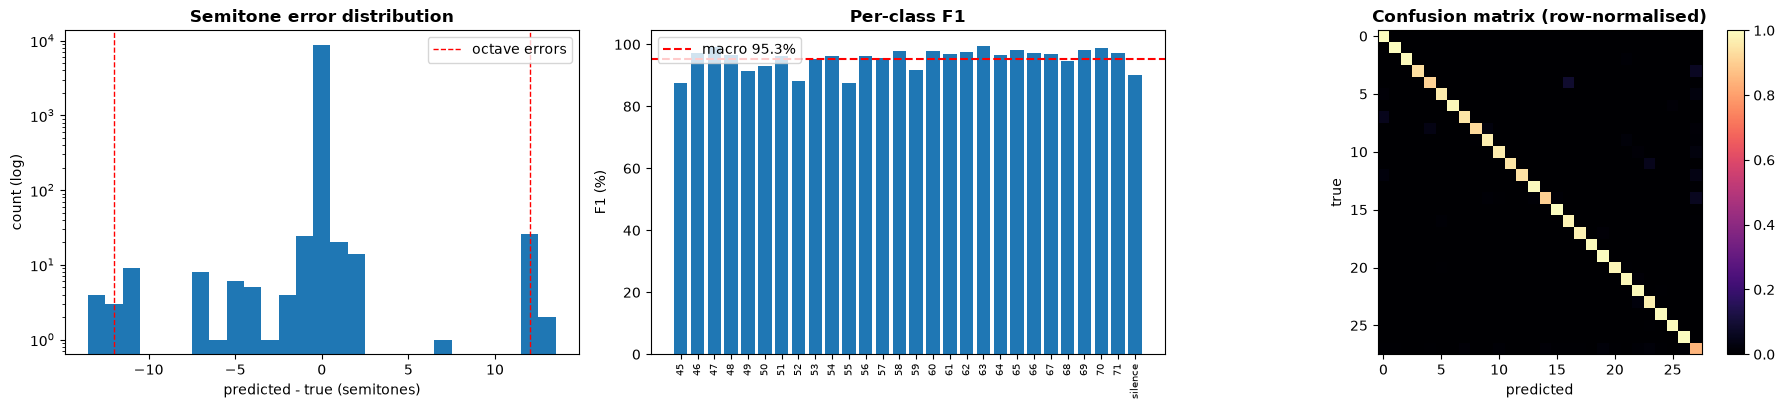

Per-class detail (paste into a backup slide):


,test samples,F1 (%)
class,,
45,87,87.4
46,141,97.2
47,126,99.2
48,92,96.6
49,172,91.5
50,147,93.1
51,76,96.2
52,150,88.2
53,77,95.3



Of all pitch predictions: exact 98.6%  |  off-by-one-semitone 0.5%  |  octave errors 0.3%


In [21]:
yt_t, yp_t = collect(teacher_model, test_ds)
yt_s, yp_s = collect(student_model, test_ds)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

# --- semitone error histogram ---
m = np.array([midi_of[i] if midi_of[i] is not None else -999
              for i in range(num_classes)])
keep = (m[yt_t] != -999) & (m[yp_t] != -999)
d = m[yp_t][keep] - m[yt_t][keep]
bins = np.arange(-13.5, 14.5, 1)
axes[0].hist(np.clip(d, -13, 13), bins=bins, color='tab:blue')
axes[0].set_yscale('log')
axes[0].axvline(-12, color='r', ls='--', lw=1)
axes[0].axvline(12, color='r', ls='--', lw=1, label='octave errors')
axes[0].set_xlabel('predicted - true (semitones)')
axes[0].set_ylabel('count (log)')
axes[0].set_title('Semitone error distribution', fontweight='bold')
axes[0].legend()

# --- per-class F1 vs pitch ---
_, _, f1c, sup = precision_recall_fscore_support(
    yt_t, yp_t, labels=range(num_classes), zero_division=0)
xs = [midi_of[i] if midi_of[i] is not None else np.nan for i in range(num_classes)]
axes[1].bar([i for i in range(num_classes)], f1c * 100)
axes[1].set_xticks(range(num_classes))
axes[1].set_xticklabels(class_names, rotation=90, fontsize=7)
axes[1].set_ylabel('F1 (%)'); axes[1].set_title('Per-class F1', fontweight='bold')
axes[1].axhline(f1c.mean() * 100, color='r', ls='--',
                label=f'macro {f1c.mean()*100:.1f}%')
axes[1].legend()

# --- confusion matrix, ordered by pitch ---
cm = confusion_matrix(yt_t, yp_t, labels=range(num_classes), normalize='true')
im = axes[2].imshow(cm, cmap='magma', vmin=0, vmax=1)
axes[2].set_xlabel('predicted'); axes[2].set_ylabel('true')
axes[2].set_title('Confusion matrix (row-normalised)', fontweight='bold')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

print("Per-class detail (paste into a backup slide):")
per_class_df = pd.DataFrame({
    'class': class_names,
    'test samples': sup,
    'F1 (%)': (f1c * 100).round(1),
}).set_index('class')
display(per_class_df)

off_by_one = float((np.abs(d) == 1).mean())
octave = float(((np.abs(d) % 12 == 0) & (np.abs(d) >= 12)).mean())
print(f"\nOf all pitch predictions: exact {float((d==0).mean())*100:.1f}%  |  "
      f"off-by-one-semitone {off_by_one*100:.1f}%  |  octave errors {octave*100:.1f}%")

## 8c. Slide 5 — compression comparison with resource measurements

This is the slide that carries the TinyML story. Task metric **and** resource
cost, on the same row, for every configuration.

`RAM (arena)` is what TFLM needs for activations; the ESP32 sketch prints the
exact figure via `arena_used_bytes()` at boot, which is the number to put on the
slide. Flash is the model plus the TFLM runtime — read it from the Arduino IDE
compile output. Latency comes from the on-device timing print.

In [22]:
def keras_size_kb(model, path='_tmp.h5'):
    model.save(path); kb = os.path.getsize(path) / 1024; os.remove(path); return kb


def tflite_arena_estimate(tflite_bytes):
    """Rough activation-memory estimate. The authoritative number is what the
    ESP32 prints from arena_used_bytes() -- use that on the slide."""
    it = tf.lite.Interpreter(model_content=tflite_bytes)
    it.allocate_tensors()
    total = 0
    for d in it.get_tensor_details():
        if d['shape'].size == 0:
            continue
        total = max(total, int(np.prod(d['shape'])))
    return total


configs = []

yt, yp = collect(teacher_model, test_ds)
configs.append(('Teacher (log-freq CNN, float32)', keras_size_kb(teacher_model),
                teacher_model.count_params(), yt, yp))

yt, yp = collect(student_model, test_ds)
configs.append(('Student (distilled, float32)', keras_size_kb(student_model),
                student_model.count_params(), yt, yp))

yt, yp = collect(stripped_sparse_model, test_ds)
configs.append(('Student (pruned 50%, float32)', keras_size_kb(stripped_sparse_model),
                stripped_sparse_model.count_params(), yt, yp))

yt, yp = tflite_collect(DEPLOY_PATH, test_ds)
configs.append(('Student (pruned + INT8) -- DEPLOYED',
                os.path.getsize(DEPLOY_PATH) / 1024,
                stripped_sparse_model.count_params(), yt, yp))

rows = []
for name, kb, params, yt_, yp_ in configs:
    s = summarise(name, yt_, yp_)
    s['Size (KB)'] = round(kb, 1)
    s['Params'] = f"{params:,}"
    rows.append(s)

slide5 = pd.DataFrame(rows).set_index('Model')
for c in ['Accuracy', 'Macro F1', 'Weighted F1', 'Acc +/-1 semitone', 'Octave err']:
    slide5[c] = (slide5[c] * 100).round(2)
slide5 = slide5[['Accuracy', 'Macro F1', 'Weighted F1', 'Acc +/-1 semitone',
                 'Octave err', 'Size (KB)', 'Params']]
print("=== SLIDE 5: compression comparison ===")
display(slide5)

base = slide5['Accuracy'].iloc[0]
dep = slide5['Accuracy'].iloc[-1]
sz0, sz1 = slide5['Size (KB)'].iloc[0], slide5['Size (KB)'].iloc[-1]
fl = slide5['Accuracy'].iloc[2]
print(f"\nHeadline numbers for the slide:")
print(f"  size reduction, teacher -> deployed : {sz0/sz1:.1f}x  ({sz0:.1f} -> {sz1:.1f} KB)")
print(f"  accuracy cost of the whole pipeline : {dep-base:+.2f} pp")
print(f"  accuracy cost of INT8 alone         : {dep-fl:+.2f} pp")
print(f"\n  RAM (arena): read arena_used_bytes() from the ESP32 boot print")
print(f"  Flash      : read the Arduino IDE compile output")
print(f"  Latency    : enable the timing printf in loop() on the ESP32")

/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


=== SLIDE 5: compression comparison ===


,Accuracy,Macro F1,Weighted F1,Acc +/-1 semitone,Octave err,Size (KB),Params
Model,,,,,,,
"Teacher (log-freq CNN, float32)",95.43,95.35,95.38,99.05,0.33,786.4,"62,708"
"Student (distilled, float32)",94.53,93.35,94.55,98.96,0.17,112.6,"21,896"
"Student (pruned 50%, float32)",94.53,93.35,94.55,98.96,0.17,112.6,"21,896"
Student (pruned + INT8) -- DEPLOYED,94.31,93.07,94.34,98.94,0.16,27.8,"21,896"



Headline numbers for the slide:
  size reduction, teacher -> deployed : 28.3x  (786.4 -> 27.8 KB)
  accuracy cost of the whole pipeline : -1.12 pp
  accuracy cost of INT8 alone         : -0.22 pp

  RAM (arena): read arena_used_bytes() from the ESP32 boot print
  Flash      : read the Arduino IDE compile output
  Latency    : enable the timing printf in loop() on the ESP32


## 8d. Slide 5 — on-device evaluation template

The rubric requires **at least 10–15 actual on-device samples per class**, with
the count explicitly stated. Offline test accuracy does not satisfy this — it
has to be the deployed device producing the predictions.

The practical way to get 15 × ~30 classes without playing guitar for an hour is
to play held-out test clips through a speaker at the microphone. That is still a
genuine on-device sample: real acoustic path, real microphone, real firmware.
Play a few notes live during the demo itself to show it works on a real
instrument too.

This cell exports a stratified playlist from the **test** split (never training
data) plus a CSV to record predictions in.

In [23]:
import shutil as _sh

N_PER_CLASS = 15          # rubric: at least 10-15 per class
ONDEVICE_DIR = 'ondevice_eval'

_sh.rmtree(ONDEVICE_DIR, ignore_errors=True)
os.makedirs(ONDEVICE_DIR, exist_ok=True)

by_class = {}
for p, l in zip(test_paths, test_labels):
    by_class.setdefault(l, []).append(p)

rng_od = np.random.RandomState(0)
manifest = []
for ci in sorted(by_class):
    pool = by_class[ci]
    pick = rng_od.choice(pool, size=min(N_PER_CLASS, len(pool)), replace=False)
    for k, src in enumerate(pick):
        dst = os.path.join(ONDEVICE_DIR, f"{class_names[ci]}__{k:02d}.wav")
        _sh.copy(src, dst)
        manifest.append({'file': os.path.basename(dst),
                         'true_class': class_names[ci],
                         'predicted_class': '',
                         'correct': ''})

pd.DataFrame(manifest).to_csv(os.path.join(ONDEVICE_DIR, 'ondevice_results.csv'),
                              index=False)

counts = pd.Series([m['true_class'] for m in manifest]).value_counts().sort_index()
print(f"{len(manifest)} clips across {len(by_class)} classes -> {ONDEVICE_DIR}/")
print(f"samples per class: min {counts.min()}, max {counts.max()}")
if counts.min() < 10:
    print(f"  WARNING: {(counts < 10).sum()} class(es) have <10 test clips available.")
    print("  State the actual per-class counts on the slide rather than rounding up.")
print("\nProcedure:")
print("  1. Flash the ESP32 and open the Serial Monitor.")
print("  2. Play each clip through a speaker ~15 cm from the microphone.")
print("  3. Record the predicted note in ondevice_results.csv.")
print("  4. Run the scoring cell below.")

420 clips across 28 classes -> ondevice_eval/
samples per class: min 15, max 15

Procedure:
  1. Flash the ESP32 and open the Serial Monitor.
  2. Play each clip through a speaker ~15 cm from the microphone.
  3. Record the predicted note in ondevice_results.csv.
  4. Run the scoring cell below.


In [24]:
# Run AFTER filling in ondevice_results.csv.
csv_path = os.path.join(ONDEVICE_DIR, 'ondevice_results.csv')
od = pd.read_csv(csv_path, dtype=str).fillna('')
od = od[od['predicted_class'].str.strip() != '']

if len(od) == 0:
    print("No predictions recorded yet -- fill in the predicted_class column first.")
else:
    od['correct'] = (od['true_class'] == od['predicted_class']).astype(int)
    per = od.groupby('true_class').agg(
        **{'# On-Device Samples': ('correct', 'size'),
           'Correct': ('correct', 'sum')})
    per['Accuracy (%)'] = (per['Correct'] / per['# On-Device Samples'] * 100).round(1)
    overall = pd.DataFrame({'# On-Device Samples': [len(od)],
                            'Correct': [int(od['correct'].sum())],
                            'Accuracy (%)': [round(od['correct'].mean() * 100, 1)]},
                           index=['OVERALL'])
    table = pd.concat([per, overall])
    print("=== SLIDE 5: on-device evaluation ===")
    display(table)
    print(f"\nTotal on-device samples: {len(od)}  "
          f"({per['# On-Device Samples'].min()}-{per['# On-Device Samples'].max()} per class)")

    offline = slide5['Accuracy'].iloc[-1]
    print(f"offline INT8 test accuracy : {offline:.2f}%")
    print(f"on-device accuracy         : {od['correct'].mean()*100:.2f}%")
    print(f"acoustic-path gap          : {od['correct'].mean()*100 - offline:+.2f} pp")
    print("\nThe gap is a real finding, not an error -- it isolates everything the")
    print("offline number cannot see: microphone response, room reverberation,")
    print("speaker colouration, and background noise.")

No predictions recorded yet -- fill in the predicted_class column first.


### 8e. Quick recheck: the low register

A last per-class accuracy plot, called out separately because the low MIDI numbers were where the old 64 ms / linear-frequency front end failed hardest — this checks whether that floor actually lifted.

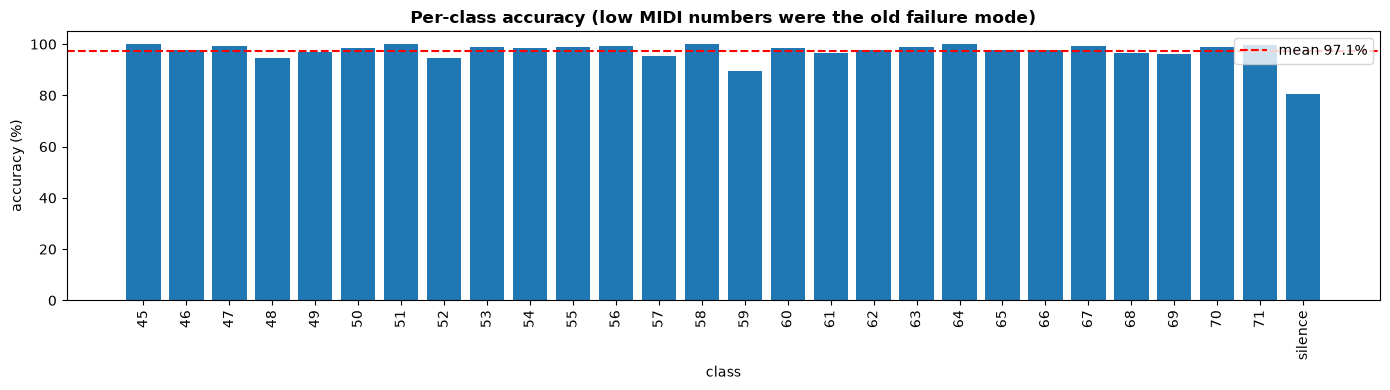

In [25]:
# Per-class accuracy. The old representation failed hardest on LOW notes,
# where the fundamental was unresolvable -- check that the floor has lifted.
y_true, y_pred = [], []
for xb, yb in test_ds:
    y_pred.extend(np.argmax(student_model.predict(xb, verbose=0), axis=1))
    y_true.extend(yb.numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

per_class = [( (y_pred[y_true == i] == i).mean() if (y_true == i).any() else np.nan)
             for i in range(num_classes)]

plt.figure(figsize=(14, 4))
plt.bar(range(num_classes), np.array(per_class) * 100)
plt.xticks(range(num_classes), class_names, rotation=90)
plt.ylabel("accuracy (%)"); plt.xlabel("class")
plt.title("Per-class accuracy (low MIDI numbers were the old failure mode)",
          fontweight='bold')
plt.axhline(np.nanmean(per_class) * 100, color='r', ls='--',
            label=f'mean {np.nanmean(per_class) * 100:.1f}%')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Export the C headers

Writes four files for the `midi_note_esp32/` sketch folder:

| file | contents |
|---|---|
| `model.h` | the INT8 model bytes, 16-byte aligned |
| `model_params.h` | geometry, labels, quantization reference |
| `filterbank.h` | the 217 triangular filters, sparse |
| `golden_test.h` | one real clip + expected features + expected output |

The filterbank is stored sparsely (start index + run of weights per bin) because
it is only ~0.5% dense — storing it as a full 217×1025 matrix would be 890 KB.

In [26]:
from pathlib import Path


def c_array(name, data, per_line=12, fmt="0x{:02x}", ctype="unsigned char",
            prefix=""):
    lines = [f"{prefix}const {ctype} {name}[] = {{"]
    for i in range(0, len(data), per_line):
        lines.append("  " + ", ".join(fmt.format(v) for v in data[i:i + per_line]) + ",")
    lines.append("};")
    lines.append(f"const unsigned int {name}_len = {len(data)};")
    return "\n".join(lines)


# ---- model.h --------------------------------------------------------------
Path("model.h").write_text("\n".join([
    "// AUTO-GENERATED. Do not edit.",
    "#pragma once",
    "",
    "// alignas(16): TFLM reads the FlatBuffer in place and requires 16-byte",
    "// alignment. Without it GetModel() may fault or silently misparse.",
    c_array("g_model", Path(DEPLOY_PATH).read_bytes(), prefix="alignas(16) "),
    "",
]), encoding="utf-8")

# ---- filterbank.h ---------------------------------------------------------
starts, lengths, weights = [], [], []
for i in range(N_LOG_BINS):
    nz = np.nonzero(FILTERBANK[i])[0]
    starts.append(int(nz[0]))
    lengths.append(int(nz[-1] - nz[0] + 1))
    weights.extend(FILTERBANK[i, nz[0]:nz[-1] + 1].tolist())

Path("filterbank.h").write_text("\n".join([
    "// AUTO-GENERATED. Do not edit.",
    "// Sparse log-frequency triangular filterbank.",
    "// Bin i accumulates kFbWeights[offset_i ...] against",
    "// magnitude[kFbStart[i] ... kFbStart[i]+kFbLength[i]-1], where offset_i",
    "// is the running sum of kFbLength[0..i-1].",
    "#pragma once",
    "",
    c_array("kFbStart",  starts,  per_line=16, fmt="{}", ctype="unsigned short"),
    "",
    c_array("kFbLength", lengths, per_line=16, fmt="{}", ctype="unsigned short"),
    "",
    c_array("kFbWeights", weights, per_line=8, fmt="{:.8f}f", ctype="float"),
    "",
]), encoding="utf-8")

# ---- model_params.h -------------------------------------------------------
labels_c = ",\n".join(f'  "{c}"' for c in class_names)
Path("model_params.h").write_text(f"""// AUTO-GENERATED. Do not edit.
#pragma once

// ---- audio front end -----------------------------------------------------
constexpr int   kSampleRate    = {SAMPLE_RATE};
constexpr int   kWindowSamples = {AUDIO_LENGTH};   // 64 ms
constexpr int   kFFTSize       = {FFT_SIZE};       // zero-padded from kWindowSamples
constexpr int   kNumFFTBins    = {FFT_SIZE // 2 + 1};
constexpr int   kNumLogBins    = {N_LOG_BINS};
constexpr float kLogEps        = {LOG_EPS}f;
constexpr float kLogTopRange   = {LOG_TOP_RANGE}f;

// Model input is (kNumLogBins, 1, 1).
constexpr int kFeatureElements = {N_LOG_BINS};

// ---- filterbank geometry (informational) ---------------------------------
constexpr int kMidiLow      = {MIDI_LOW};
constexpr int kMidiHigh     = {MIDI_HIGH};
constexpr int kBinsPerSemi  = {BINS_PER_SEMI};

// ---- model ---------------------------------------------------------------
constexpr int kCategoryCount = {num_classes};

constexpr float kRefInputScale  = {in_scale:.10f}f;
constexpr int   kRefInputZero   = {in_zp};
constexpr float kRefOutputScale = {out_scale:.10f}f;
constexpr int   kRefOutputZero  = {out_zp};

inline const char* const kCategoryLabels[kCategoryCount] = {{
{labels_c}
}};

constexpr int kSilenceIndex = {class_names.index('silence') if 'silence' in class_names else -1};
""", encoding="utf-8")

# ---- golden_test.h --------------------------------------------------------
golden_audio = golden_label = None
for xb, yb in test_raw.map(load_audio).batch(64).take(20):
    for a, l in zip(xb.numpy(), yb.numpy()):
        if class_names[int(l)] != "silence" and np.abs(a).max() > 1e-3:
            golden_audio, golden_label = a, int(l)
            break
    if golden_audio is not None:
        break
assert golden_audio is not None, "no usable non-silence test clip found"

golden_feat = get_features(tf.constant(golden_audio), 0)[0].numpy().squeeze()
q = np.clip(np.round(golden_feat.reshape(N_LOG_BINS, 1, 1) / in_scale + in_zp),
            -128, 127).astype(np.int8)[None, ...]
interp.set_tensor(in_det["index"], q); interp.invoke()
golden_out = interp.get_tensor(out_det["index"])[0]

Path("golden_test.h").write_text("\n".join([
    "// AUTO-GENERATED. Do not edit.",
    f"// True label: {class_names[golden_label]}",
    "#pragma once",
    "",
    f"constexpr int kGoldenLabelIndex = {golden_label};",
    "",
    "// Raw waveform as tf.audio.decode_wav produced it.",
    c_array("kGoldenAudio", golden_audio.tolist(), per_line=8,
            fmt="{:.8f}f", ctype="float"),
    "",
    "// Expected log-frequency features (post log, post mean-subtraction).",
    c_array("kGoldenFeatures", golden_feat.tolist(), per_line=8,
            fmt="{:.8f}f", ctype="float"),
    "",
    "// Desktop TFLite output for the quantized golden features.",
    c_array("kGoldenOutput", golden_out.tolist(), per_line=16,
            fmt="{}", ctype="signed char"),
    "",
]), encoding="utf-8")

for f in ("model.h", "model_params.h", "filterbank.h", "golden_test.h"):
    print(f"{f:18s} {Path(f).stat().st_size / 1024:8.1f} KB")

print(f"\ngolden clip: true={class_names[golden_label]}  "
      f"predicted={class_names[int(np.argmax(golden_out))]}")

model.h               171.6 KB
model_params.h          1.3 KB
filterbank.h           18.6 KB
golden_test.h          30.9 KB

golden clip: true=45  predicted=45


On Colab, download the four generated header files (plus the `.tflite` file) to your machine. Outside Colab they are already sitting in the working directory.

In [27]:
try:
    from google.colab import files
    for f in ("model.h", "model_params.h", "filterbank.h", "golden_test.h",
              DEPLOY_PATH):
        files.download(f)
except ImportError:
    print("Not on Colab -- files are in the working directory.")

print("\nCopy the four .h files into midi_note_esp32/ and rebuild.")

Not on Colab -- files are in the working directory.

Copy the four .h files into midi_note_esp32/ and rebuild.


## 10. Firmware notes

The sketch needs three changes to match this front end. Updated
`feature_provider.cpp` and `fft.h` are supplied alongside this notebook.

1. **`fft.h`** — raise `kFFTMaxSize` from 1024 to 2048.
2. **`feature_provider.cpp`** — replace the 29-frame STFT loop with: one
   2048-point zero-padded FFT over the whole window, the sparse filterbank
   accumulation, `logf`, then mean subtraction.
3. **`midi_note_esp32.ino`** — the golden test now compares against
   `kGoldenFeatures` rather than `kGoldenSpec`.

Two things get *easier*:

- **`kMicGain` no longer matters much.** The features are gain-invariant, so
  the calibration step in the README drops from mandatory to a sanity check.
  Keep the RMS gate — it still stops the recognizer chewing on room noise.
- **Compute drops.** 29 128-point FFTs become one 2048-point FFT, and the model
  is ~10x smaller. Expect the tensor arena to fall to roughly 25 KB, and
  `kHopSamples` could go to 256 (16 ms) if you want faster response.